In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader
from PIL import Image
from PIL import Image, ImageOps

from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter
import polars as pl


Training data
book: 24 images
cup: 24 images
chair: 24 images
laptop: 24 images

Validation data
book: 6 images
cup: 6 images
chair: 6 images
laptop: 6 images

Real_Front data
book: 3 images
cup: 3 images
chair: 3 images
laptop: 3 images

Real_Side data
book: 3 images
cup: 3 images
chair: 3 images
laptop: 3 images

Real_Top data
book: 3 images
cup: 3 images
chair: 3 images
laptop: 3 images
training Images











MODEL 1 results
----------------------
Training Accuracy: 100.00%
Validation Accuracy: 100.00%
Real Front Accuracy: 58.33%
Real Side Accuracy: 58.33%
Real Top Accuracy: 33.33%

Front Accuracy
book: 0/3 (0.00%)
chair: 1/3 (33.33%)
cup: 3/3 (100.00%)
laptop: 3/3 (100.00%)

Side Accuracy
book: 2/3 (66.67%)
chair: 0/3 (0.00%)
cup: 3/3 (100.00%)
laptop: 2/3 (66.67%)

Top Accuracy
book: 1/3 (33.33%)
chair: 0/3 (0.00%)
cup: 3/3 (100.00%)
laptop: 0/3 (0.00%)

Multi-View Accuracy
-------------------------
book: 3/9 (33.33%)
chair: 1/9 (11.11%)
cup: 9/9 (100.00%)
laptop: 5/9 (55.56%

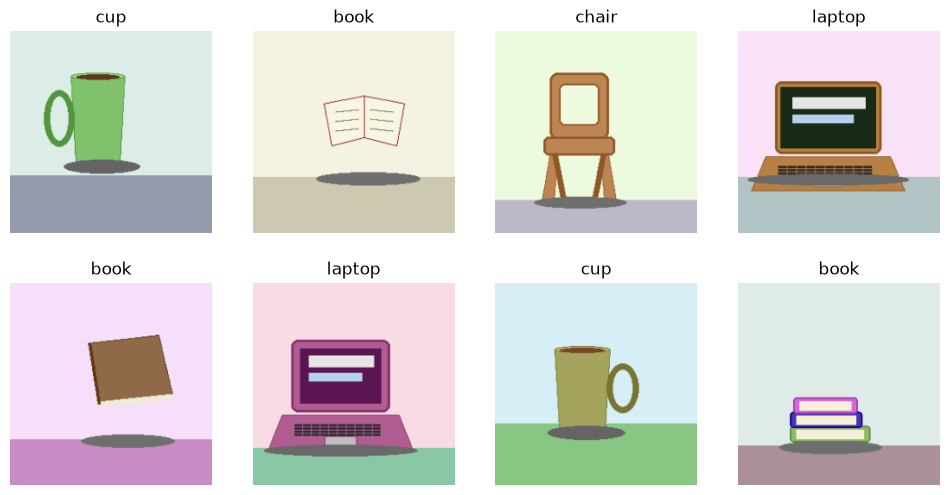

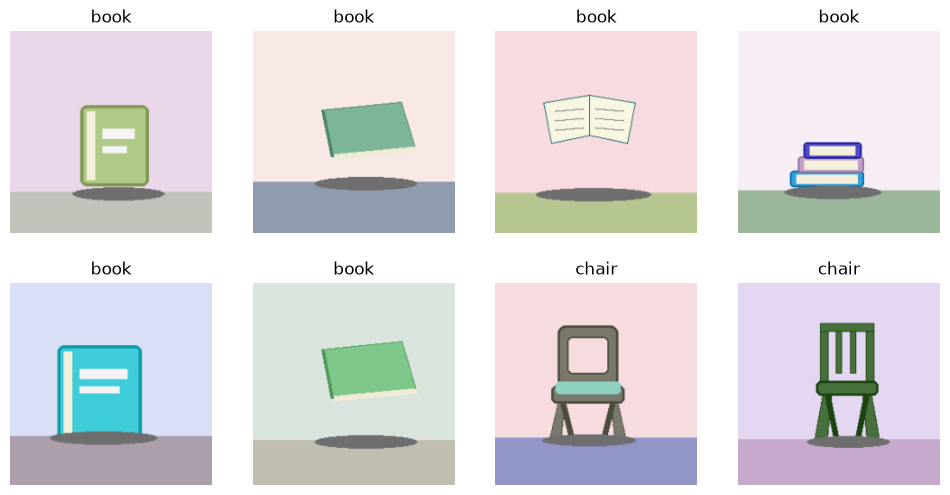

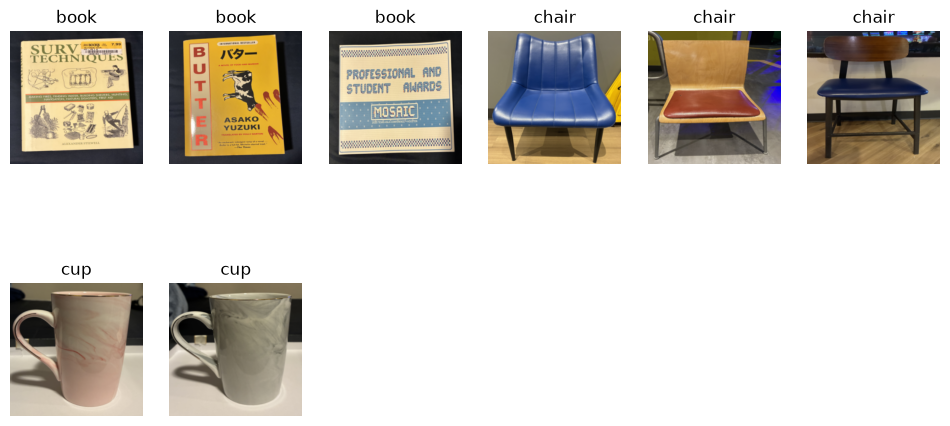

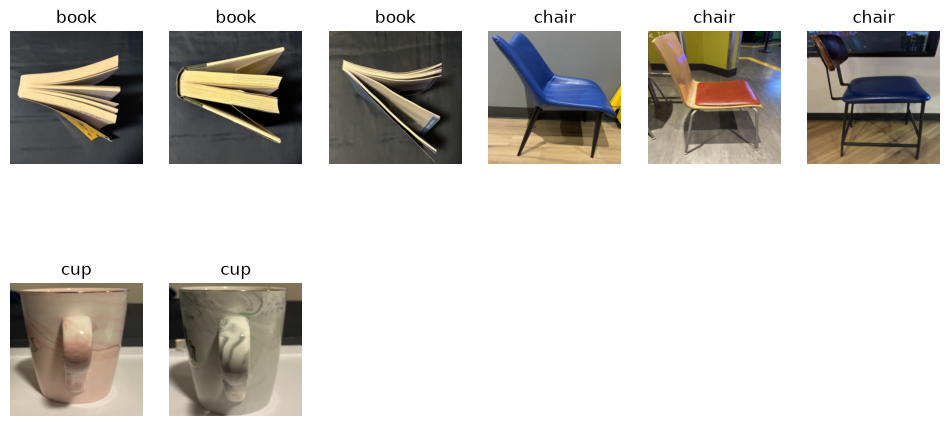

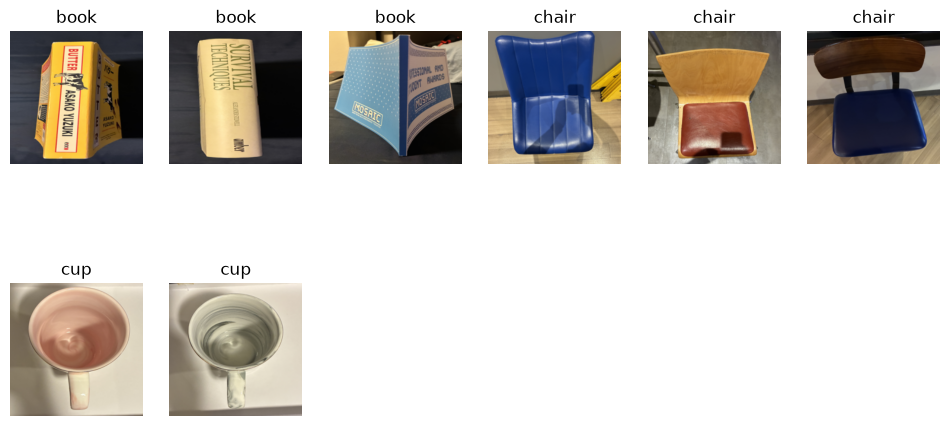

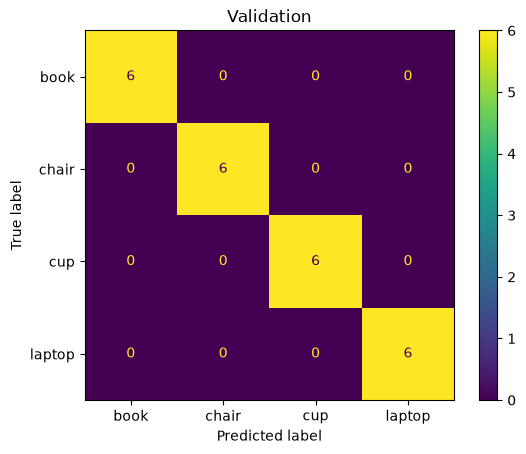

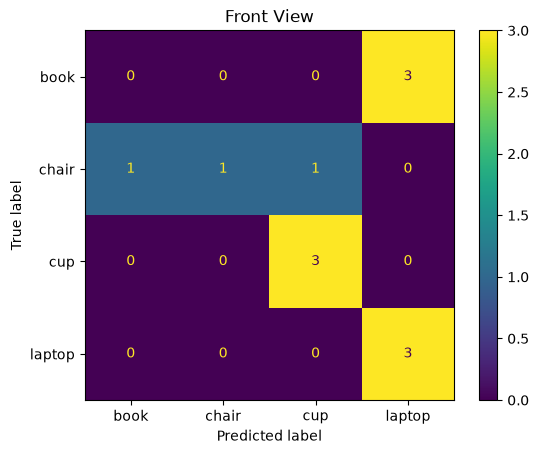

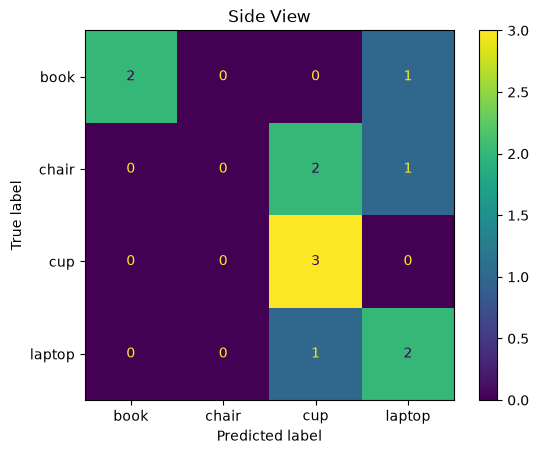

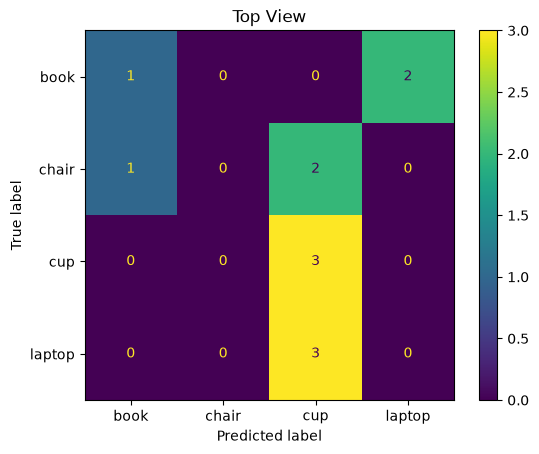

In [8]:
device = "cpu"
data_path = Path(r"C:\Users\gar07835\OneDrive - Texas Tech University\TTU - School\Grad Classes\Summer - 2026\ar_project\model_01")
train_directory = data_path / "train"
val_directory = data_path / "val"
real_front_dir = data_path / "data_real_front"
real_side_dir = data_path / "data_real_side"
real_top_dir = data_path / "data_real_top"

class_names = ["book", "cup", "chair", "laptop"]
images_extensions = {".jpg", ".png"}

for split_name, split_dir in [("Training", train_directory), ("Validation", val_directory),
("Real_Front", real_front_dir), ("Real_Side", real_side_dir), ("Real_Top", real_top_dir)]:
    print(f"\n{split_name} data")

    for class_name in class_names:
        class_directory = split_dir / class_name
        images = [
            file
            for file in class_directory.iterdir()
            if file.is_file() and file.suffix.lower() in images_extensions]

        print(f"{class_name}: {len(images)} images")

image_transfer = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
train_data = datasets.ImageFolder(root = train_directory, transform = image_transfer)
val_data = datasets.ImageFolder(root = val_directory, transform = image_transfer)
real_front = datasets.ImageFolder(root = real_front_dir, transform = image_transfer)
real_side = datasets.ImageFolder(root = real_side_dir, transform = image_transfer)
real_top = datasets.ImageFolder(root = real_top_dir, transform = image_transfer)
image, label = train_data[0]

train_loader = DataLoader(train_data, batch_size = 8, shuffle = True)
val_loader = DataLoader(val_data, batch_size = 8, shuffle = False)
front_loader = DataLoader(real_front, batch_size = 8, shuffle = False)
side_loader = DataLoader(real_side, batch_size = 8, shuffle = False)
top_loader = DataLoader(real_top, batch_size = 8, shuffle = False)

t_images, t_labels = next(iter(train_loader))
v_images, v_labels = next(iter(val_loader))
f_images, f_labels = next(iter(front_loader))
s_images, s_labels = next(iter(side_loader))
top_images, top_labels = next(iter(top_loader))
images_train = train_data.classes

print("training Images")
plt.figure(figsize = (12, 6))
for i in range(len(t_images)):
    t_image = t_images[i].permute(1, 2, 0)
    plt.subplot(2, 4, i + 1)
    plt.imshow(t_image)
    plt.title(images_train[t_labels[i].item()])
    plt.axis(False)

plt.figure(figsize = (12, 6))
for i in range(len(v_images)):
    v_image = v_images[i].permute(1, 2, 0)
    plt.subplot(2, 4, i + 1)
    plt.imshow(v_image)
    plt.title(images_train[v_labels[i].item()])
    plt.axis(False)

plt.figure(figsize = (12, 6))
for i in range(len(f_images)):
    f_image = f_images[i].permute(1, 2, 0)
    plt.subplot(2, 6, i + 1)
    plt.imshow(f_image)
    plt.title(images_train[f_labels[i].item()])
    plt.axis(False)

plt.figure(figsize = (12, 6))
for i in range(len(s_images)):
    s_image = s_images[i].permute(1, 2, 0)
    plt.subplot(2, 6, i + 1)
    plt.imshow(s_image)
    plt.title(images_train[s_labels[i].item()])
    plt.axis(False)

plt.figure(figsize = (12, 6))
for i in range(len(top_images)):
    top_image = top_images[i].permute(1, 2, 0)
    plt.subplot(2, 6, i + 1)
    plt.imshow(top_image)
    plt.title(images_train[top_labels[i].item()])
    plt.axis(False)

model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)
model.fc = nn.Linear(num_features, 4)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
num_epoches = 10

for epoch in range(num_epoches):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        train_images = images.to(device)
        train_labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(train_images)
        loss = criterion(outputs, train_labels)
        loss.backward()
        optimizer.step()

        _, predictions = torch.max(outputs, 1)
        train_loss += loss.item() * train_images.size(0)
        train_correct += (predictions == train_labels).sum().item()
        train_total += train_labels.size(0)

    train_accuracy = train_correct / train_total
    train_loss = train_loss / train_total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    validation_labels = []
    validation_predictions = []

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)

            outputs = model(val_images)
            loss = criterion(outputs, val_labels)
            _, val_predictions = torch.max(outputs, 1)
            val_loss += loss.item() * val_images.size(0)
            val_correct += (val_predictions == val_labels).sum().item()
            val_total += val_labels.size(0)
            validation_labels.extend(val_labels.cpu().tolist())
            validation_predictions.extend(val_predictions.cpu().tolist())

        val_accuracy = val_correct / val_total
        val_loss = val_loss / val_total
        
    model.eval()
    front_loss = 0
    front_correct = 0
    front_total = 0
    real_front_labels = []
    real_front_predictions = []

    with torch.no_grad():
        for front_images, front_labels in front_loader:
            front_images = front_images.to(device)
            front_labels = front_labels.to(device)
            outputs = model(front_images)
            loss = criterion(outputs, front_labels)
            _, front_predicitons = torch.max(outputs, 1)
            front_loss += loss.item() * front_images.size(0)
            front_correct += (front_predicitons == front_labels).sum().item()
            front_total += front_labels.size(0)
            real_front_labels.extend(front_labels.cpu().tolist())
            real_front_predictions.extend(front_predicitons.cpu().tolist())

        front_accuracy = front_correct / front_total
        front_loss = front_loss / front_total

    model.eval()
    side_loss = 0
    side_correct = 0
    side_total = 0
    real_side_labels = []
    real_side_predicitions = []

    with torch.no_grad():
        for side_images, side_labels in side_loader:
            side_images = side_images.to(device)
            side_labels = side_labels.to(device)
            outputs = model(side_images)
            loss = criterion(outputs, side_labels)
            _, side_preddicitions = torch.max(outputs, 1)
            side_loss += loss.item() * side_images.size(0)
            side_correct += (side_preddicitions == side_labels).sum().item()
            side_total += side_labels.size(0)
            real_side_labels.extend(side_labels.cpu().tolist())
            real_side_predicitions.extend(side_preddicitions.cpu().tolist())

        side_accuracy = side_correct / side_total
        side_loss = side_loss / side_total

    model.eval()
    top_loss = 0
    top_correct = 0
    top_total = 0
    real_top_labels = []
    real_top_predicitions = []

    with torch.no_grad():
        for top1_images, top1_labels in top_loader:
            top1_images = top1_images.to(device)
            top1_labels = top1_labels.to(device)
            outputs = model(top1_images)
            loss = criterion(outputs, top1_labels)
            _, top_predicitions = torch.max(outputs, 1)
            top_loss += loss.item() * top1_images.size(0)
            top_correct += (top_predicitions == top1_labels).sum().item()
            top_total += top1_labels.size(0)
            real_top_labels.extend(top1_labels.cpu().tolist())
            real_top_predicitions.extend(top_predicitions.cpu().tolist())

        top_accuracy = top_correct / top_total
        top_loss = top_loss / top_total

    print()
    epoch_results = []
    for epoch in range(num_epoches):
        epoch_results.append({
        "Epoch": epoch + 1,
        "Train_Loss": train_loss,
        "Train_Accuracy": train_accuracy,
        "Validation_Loss": val_loss,
        "Validation_Accuracy": val_accuracy,
        "Real_Front_Loss": front_loss,
        "Real_Front_Accuracy": front_accuracy,
        "Real_Side_Loss": side_loss,
        "Real_Side_Accuracy": side_accuracy,
        "Real_Top_Loss": top_loss,
        "Real_Top_Accuracy": top_accuracy
    })
        
df = pl.DataFrame(epoch_results)
#print(df.head(10))

final_row = df.row(-1, named=True)
print("\nMODEL 1 results")
print("----------------------")
print(f"Training Accuracy: {final_row['Train_Accuracy'] * 100:.2f}%")
print(f"Validation Accuracy: {final_row['Validation_Accuracy'] * 100:.2f}%")
print(f"Real Front Accuracy: {final_row['Real_Front_Accuracy'] * 100:.2f}%")
print(f"Real Side Accuracy: {final_row['Real_Side_Accuracy'] * 100:.2f}%")
print(f"Real Top Accuracy: {final_row['Real_Top_Accuracy'] * 100:.2f}%")

cm_v = confusion_matrix(validation_labels, validation_predictions)
cm_f = confusion_matrix(real_front_labels, real_front_predictions)
cm_s = confusion_matrix(real_side_labels, real_side_predicitions)
cm_t = confusion_matrix(real_top_labels, real_top_predicitions)

display_v = ConfusionMatrixDisplay(confusion_matrix = cm_v, display_labels = val_data.classes)
display_f = ConfusionMatrixDisplay(confusion_matrix = cm_f, display_labels = real_front.classes)
display_s = ConfusionMatrixDisplay(confusion_matrix = cm_s, display_labels = real_side.classes)
display_t = ConfusionMatrixDisplay(confusion_matrix = cm_t, display_labels = real_top.classes)

display_v.plot()
plt.title("Validation")

display_f.plot()
plt.title("Front View")

display_s.plot()
plt.title("Side View")

display_t.plot()
plt.title("Top View")

if epoch == num_epoches -1:
    print("\nFront Accuracy")
    for class_index, class_name in enumerate(real_front.classes):
        class_total = sum(label == class_index for label in real_front_labels)
        class_correct = sum(label == class_index and predictions == class_index for label, predictions in zip(
            real_front_labels, real_front_predictions
        ))
        class_accuracy = (class_correct / class_total if class_total > 0 else 0.0)
        print(
            f"{class_name}: "
            f"{class_correct}/{class_total} "
            f"({class_accuracy:.2%})"
        )

if epoch == num_epoches -1:
    print("\nSide Accuracy")
    for class_index, class_name in enumerate(real_side.classes):
        class_total = sum(label == class_index for label in real_side_labels)
        class_correct = sum(label == class_index and predictions == class_index for label, predictions in zip(
            real_side_labels, real_side_predicitions
        ))
        class_accuracy = (class_correct / class_total if class_total > 0 else 0.0)
        print(
            f"{class_name}: "
            f"{class_correct}/{class_total} "
            f"({class_accuracy:.2%})"
        )

if epoch == num_epoches -1:
    print("\nTop Accuracy")
    for class_index, class_name in enumerate(real_top.classes):
        class_total = sum(label == class_index for label in real_top_labels)
        class_correct = sum(label == class_index and predictions == class_index for label, predictions in zip(
            real_top_labels, real_top_predicitions
        ))
        class_accuracy = (class_correct / class_total if class_total > 0 else 0.0)
        print(
            f"{class_name}: "
            f"{class_correct}/{class_total} "
            f"({class_accuracy:.2%})"
        )

print("\nMulti-View Accuracy")
print("-------------------------")

for class_index, class_name in enumerate(real_front.classes):

    front_correct = sum(
        label == class_index and pred == class_index
        for label, pred in zip(real_front_labels, real_front_predictions)
    )

    side_correct = sum(
        label == class_index and pred == class_index
        for label, pred in zip(real_side_labels, real_side_predicitions)
    )

    top_correct = sum(
        label == class_index and pred == class_index
        for label, pred in zip(real_top_labels, real_top_predicitions)
    )

    total = (
        sum(label == class_index for label in real_front_labels) +
        sum(label == class_index for label in real_side_labels) +
        sum(label == class_index for label in real_top_labels)
    )

    correct = front_correct + side_correct + top_correct

    print(
        f"{class_name}: "
        f"{correct}/{total} "
        f"({correct/total:.2%})"
    )

objects_correct = 0
objects_total = len(real_front.classes)

for class_index in range(len(real_front.classes)):

    front_ok = any(
        label == class_index and pred == class_index
        for label, pred in zip(real_front_labels, real_front_predictions)
    )

    side_ok = any(
        label == class_index and pred == class_index
        for label, pred in zip(real_side_labels, real_side_predicitions)
    )

    top_ok = any(
        label == class_index and pred == class_index
        for label, pred in zip(real_top_labels, real_top_predicitions)
    )

    if front_ok and side_ok and top_ok:
        objects_correct += 1

print(f"\nMulti-View Success Rate: {objects_correct}/{objects_total} ({objects_correct/objects_total:.2%})")